In [1]:
import earthaccess
import pyarrow.parquet as pq
from setup import parquet_dir
import datetime
import matplotlib.pyplot as plt
import cartopy
import xarray as xr

In [2]:
# search region
time1 = datetime.datetime.now()
time0 = time1 - datetime.timedelta(days=180)

lat0 = -20 
lat1 = 70
lon0 = -85
lon1 = 0

Need to run at the start of every session

In [3]:
earthaccess.login()

PACE: OCI (Ocean Color Instrument)
Aqua: MODIS (Moderate Resolution Imaging Spectroradiometer) 

In [4]:
results = earthaccess.search_datasets(instrument="oci")

for item in results:
    summary = item.summary()
    print(summary["short-name"])

PACE_OCI_MI_CLOSE
PACE_OCI_L0_SCI
PACE_OCI_L1A_SCI
PACE_OCI_L1B_CLOSE
PACE_OCI_L1B_SCI
PACE_OCI_L1C_SCI
PACE_OCI_L2_UVAI_UAA_NRT
PACE_OCI_L2_UVAI_UAA
PACE_OCI_L2_AER_UAA_NRT
PACE_OCI_L2_AER_UAA
PACE_OCI_L2_AOP_NRT
PACE_OCI_L2_AOP
PACE_OCI_L2_CLOSE
PACE_OCI_L2_CLOUD_MASK_NRT
PACE_OCI_L2_CLOUD_MASK
PACE_OCI_L2_CLOUD_NRT
PACE_OCI_L2_CLOUD
PACE_OCI_L2_LANDVI_NRT
PACE_OCI_L2_LANDVI
PACE_OCI_L2_BGC_NRT
PACE_OCI_L2_BGC
PACE_OCI_L2_IOP_NRT
PACE_OCI_L2_IOP
PACE_OCI_L2_PAR_NRT
PACE_OCI_L2_PAR
PACE_OCI_L2_SFREFL_NRT
PACE_OCI_L2_SFREFL
PACE_OCI_L2_TRGAS_NRT
PACE_OCI_L2_TRGAS
PACE_OCI_L3B_CLOSE
PACE_OCI_L3B_LANDVI_NRT
PACE_OCI_L3B_LANDVI
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3B_SFREFL
PACE_OCI_L3M_UVAI_UAA_NRT
PACE_OCI_L3M_UVAI_UAA
PACE_OCI_L3M_AER_UAA_NRT
PACE_OCI_L3M_AER_UAA
PACE_OCI_L3M_AOP_NRT
PACE_OCI_L3M_AOP
PACE_OCI_L3M_CLOSE
PACE_OCI_L3M_CLOUD_MASK_NRT
PACE_OCI_L3M_CLOUD_MASK
PACE_OCI_L3M_CLOUD_NRT
PACE_OCI_L3M_CLOUD
PACE_OCI_L3M_KD_NRT
PACE_OCI_L3M_KD
PACE_OCI_L3M_LANDVI_NRT
PACE_OCI_L3M_LANDV

/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_26053/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_26053/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_26053/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/lj/ln2kqf0x2k795vs_453ytwp00000gn/T/ipykernel_26053/2542159695.py:4: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `Da

In [26]:
short_name = 'PACE_OCI_L2_BGC'

tspan = (time0.strftime('%Y-%m-%d'), time1.strftime('%Y-%m-%d'))
bbox = (lon0, lat0, lon1, lat1)
clouds = (0, 50)

results = earthaccess.search_data(
    short_name = short_name,
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)
len(results)

/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


358

In [27]:
paths = earthaccess.open(results)

/Users/epark/opt/anaconda3/envs/gobgc26/lib/python3.14/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/358 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/358 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/358 [00:00<?, ?it/s]

Open one of these files using xr.open_dataset...Note how there are no data variables, only attributes

In [28]:
fi = 3
dataset = xr.open_dataset(paths[fi])
dataset

<xarray.Dataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260212T190657.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data1/sdpsoper/vdc/vpu24/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -111.31672
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0260744094848633
    geospatial_bounds:                 POLYGON((-106.03655 7.28557,-82.10669 ...

Each file is actually a group of Datasets

In [29]:
datatree = xr.open_datatree(paths[fi])
datatree

<xarray.DataTree>
Group: /
│   Attributes: (12/47)
│       title:                             OCI Level-2 Data BGC
│       product_name:                      PACE_OCI.20260212T190657.L2.OC_BGC.V3_...
│       processing_version:                3.2
│       history:                           l2gen par=/data1/sdpsoper/vdc/vpu24/wo...
│       instrument:                        OCI
│       platform:                          PACE
│       ...                                ...
│       geospatial_lon_min:                -111.31672
│       startDirection:                    Ascending
│       endDirection:                      Ascending
│       day_night_flag:                    Day
│       earth_sun_distance_correction:     1.0260744094848633
│       geospatial_bounds:                 POLYGON((-106.03655 7.28557,-82.10669 ...
├── Group: /sensor_band_parameters
│       Dimensions:      (wavelength: 286, number_of_reflective_bands: 286)
│       Coordinates:
│         * wavelength   (wavelength) float64 2kB 315.0 316.0 ... 2.131e+03 2.258e+03
│       Dimensions without coordinates: number_of_reflective_bands
│       Data variables:
│           fwave        (wavelength) float32 1kB ...
│           vcal_gain    (number_of_reflective_bands) float32 1kB ...
│           vcal_offset  (number_of_reflective_bands) float32 1kB ...
│           F0           (number_of_reflective_bands) float32 1kB ...
│           aw           (number_of_reflective_bands) float32 1kB ...
│           bbw          (number_of_reflective_bands) float32 1kB ...
│           k_oz         (number_of_reflective_bands) float32 1kB ...
│           k_no2        (number_of_reflective_bands) float32 1kB ...
│           Tau_r        (number_of_reflective_bands) float32 1kB ...
├── Group: /scan_line_attributes
│       Dimensions:  (number_of_lines: 1710)
│       Dimensions without coordinates: number_of_lines
│       Data variables: (12/13)
│           year     (number_of_lines) float64 14kB ...
│           day      (number_of_lines) int64 14kB ...
│           msec     (number_of_lines) int64 14kB ...
│           time     (number_of_lines) datetime64[ns] 14kB ...
│           detnum   (number_of_lines) float32 7kB ...
│           mside    (number_of_lines) float32 7kB ...
│           ...       ...
│           clon     (number_of_lines) float32 7kB ...
│           elon     (number_of_lines) float32 7kB ...
│           slat     (number_of_lines) float32 7kB ...
│           clat     (number_of_lines) float32 7kB ...
│           elat     (number_of_lines) float32 7kB ...
│           csol_z   (number_of_lines) float32 7kB ...
├── Group: /geophysical_data
│       Dimensions:           (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           chlor_a           (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto      (number_of_lines, pixels_per_line) float32 9MB ...
│           pic               (number_of_lines, pixels_per_line) float32 9MB ...
│           poc               (number_of_lines, pixels_per_line) float32 9MB ...
│           chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
│           carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
│           l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
├── Group: /navigation_data
│       Dimensions:    (number_of_lines: 1710, pixels_per_line: 1272)
│       Dimensions without coordinates: number_of_lines, pixels_per_line
│       Data variables:
│           longitude  (number_of_lines, pixels_per_line) float32 9MB ...
│           latitude   (number_of_lines, pixels_per_line) float32 9MB ...
│           tilt       (number_of_lines) float32 7kB ...
│       Attributes:
│           gringpointlongitude:  [-106.03655  -82.10669  -84.69497 -111.31672]
│           gringpointlatitude:   [ 7.2855687 12.352557  30.242205  24.930702 ]
│           gringpointsequence:   [1 2 3 4

Can merge all datasets into one

In [17]:
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 78MB
Dimensions:           (wavelength: 286, number_of_reflective_bands: 286,
                       number_of_lines: 1710, pixels_per_line: 1272)
Coordinates:
  * wavelength        (wavelength) float64 2kB 315.0 316.0 ... 2.258e+03
Dimensions without coordinates: number_of_reflective_bands, number_of_lines,
                                pixels_per_line
Data variables: (12/32)
    fwave             (wavelength) float32 1kB ...
    vcal_gain         (number_of_reflective_bands) float32 1kB ...
    vcal_offset       (number_of_reflective_bands) float32 1kB ...
    F0                (number_of_reflective_bands) float32 1kB ...
    aw                (number_of_reflective_bands) float32 1kB ...
    bbw               (number_of_reflective_bands) float32 1kB ...
    ...                ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
    longitude         (number_of_lines, pixels_per_line) float32 9MB ...
    latitude          (number_of_lines, pixels_per_line) float32 9MB ...
    tilt              (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260212T190657.L2.OC_BGC.V3_...
    processing_version:                3.2
    history:                           l2gen par=/data1/sdpsoper/vdc/vpu24/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -111.31672
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0260744094848633
    geospatial_bounds:                 POLYGON((-106.03655 7.28557,-82.10669 ...

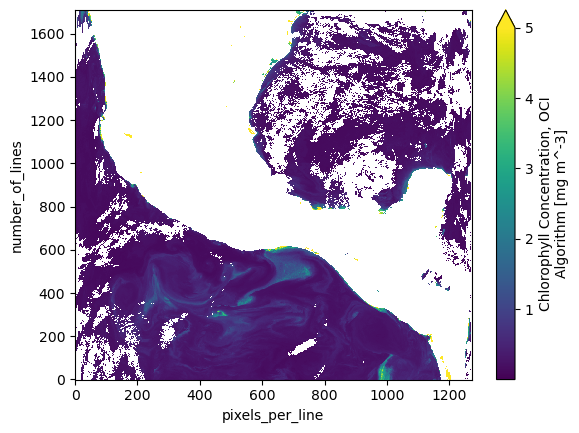

In [20]:
artist = dataset["chlor_a"].plot(vmax = 5)

In [15]:
import pyarrow.parquet as pq
from setup import parquet_dir
import datetime

In [19]:
sorted(schema.names)

['ABS_SAL_COMPUTED',
 'BBP',
 'BBP470',
 'BBP470_DATA_MODE',
 'BBP470_ERROR',
 'BBP470_QC',
 'BBP532',
 'BBP532_DATA_MODE',
 'BBP532_ERROR',
 'BBP532_QC',
 'BBP700',
 'BBP700_DATA_MODE',
 'BBP700_ERROR',
 'BBP700_QC',
 'BBP_DATA_MODE',
 'BBP_ERROR',
 'BBP_QC',
 'BISULFIDE',
 'BISULFIDE_DATA_MODE',
 'BISULFIDE_ERROR',
 'BISULFIDE_QC',
 'CDOM',
 'CDOM_DATA_MODE',
 'CDOM_ERROR',
 'CDOM_QC',
 'CHLA',
 'CHLA_DATA_MODE',
 'CHLA_ERROR',
 'CHLA_QC',
 'CONSERVATIVE_TEMP_COMPUTED',
 'CP',
 'CP660',
 'CP660_DATA_MODE',
 'CP660_ERROR',
 'CP660_QC',
 'CP_DATA_MODE',
 'CP_ERROR',
 'CP_QC',
 'CYCLE_NUMBER',
 'DATE_UPDATE',
 'DB_NAME',
 'DOWNWELLING_PAR',
 'DOWNWELLING_PAR_DATA_MODE',
 'DOWNWELLING_PAR_ERROR',
 'DOWNWELLING_PAR_QC',
 'DOWN_IRRADIANCE',
 'DOWN_IRRADIANCE380',
 'DOWN_IRRADIANCE380_DATA_MODE',
 'DOWN_IRRADIANCE380_ERROR',
 'DOWN_IRRADIANCE380_QC',
 'DOWN_IRRADIANCE412',
 'DOWN_IRRADIANCE412_DATA_MODE',
 'DOWN_IRRADIANCE412_ERROR',
 'DOWN_IRRADIANCE412_QC',
 'DOWN_IRRADIANCE443',
 'DOWN_I

In [17]:
# Setting up parquet schema
BGC_schema = pq.read_schema(parquet_dir+"_common_metadata")
dataset = pq.ParquetDataset(
    parquet_dir, 
    schema=BGC_schema
)
schema = dataset.schema
sorted(schema.names)

filter_coords_time = [
    ("JULD",">=",time0),
    ("LATITUDE",">",lat0), ("LATITUDE","<",lat1),
    ("LONGITUDE",">",lon0), ("LONGITUDE","<",lon1)
]

df = pq.ParquetDataset(parquet_dir, schema=BGC_schema, filters=filter_coords_time)
df = df.read().to_pandas()

,DB_NAME,PLATFORM_NUMBER,CYCLE_NUMBER,DATE_UPDATE,LATITUDE,LONGITUDE,JULD,PRES,PRES_QC,PRES_ERROR,...,UP_IRRADIANCE555_QC,UP_IRRADIANCE555_ERROR,UP_IRRADIANCE555_DATA_MODE,DOWNWELLING_PAR,DOWNWELLING_PAR_QC,DOWNWELLING_PAR_ERROR,DOWNWELLING_PAR_DATA_MODE,ABS_SAL_COMPUTED,CONSERVATIVE_TEMP_COMPUTED,SIGMA1_COMPUTED
0,ARGO,1902722,42,2026-05-21 23:02:09,-19.255,-36.6915,2026-04-01 09:45:54.001031168,2.45,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,37.492115,28.112495,28.219261
1,ARGO,1902722,42,2026-05-21 23:02:09,-19.255,-36.6915,2026-04-01 09:45:54.001031168,4.15,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,37.492115,28.118086,28.217342
2,ARGO,1902722,42,2026-05-21 23:02:09,-19.255,-36.6915,2026-04-01 09:45:54.001031168,6.15,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,37.492115,28.119608,28.21682
3,ARGO,1902722,42,2026-05-21 23:02:09,-19.255,-36.6915,2026-04-01 09:45:54.001031168,8.15,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,37.492115,28.119131,28.216984
4,ARGO,1902722,42,2026-05-21 23:02:09,-19.255,-36.6915,2026-04-01 09:45:54.001031168,10.15,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,37.492115,28.119652,28.216805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1679141,ARGO,7902219,49,2026-05-21 08:17:32,-1.040108,-2.577222,2026-05-21 05:53:00,1992.800049,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,35.123425,3.37061,32.431271
1679142,ARGO,7902219,49,2026-05-21 08:17:32,-1.040108,-2.577222,2026-05-21 05:53:00,1997.800049,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,35.123432,3.369151,32.431458
1679143,ARGO,7902219,49,2026-05-21 08:17:32,-1.040108,-2.577222,2026-05-21 05:53:00,2002.900024,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,35.12344,3.360795,32.432499
1679144,ARGO,7902219,49,2026-05-21 08:17:32,-1.040108,-2.577222,2026-05-21 05:53:00,2008.199951,1,<NA>,...,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,NaN,35.12244,3.351449,32.432873


In [26]:
depth_min = 10
variable_list = ['BBP700','BBP700_QC', 
                 'CHLA','CHLA_QC',
                 'CYCLE_NUMBER',
                 'DOXY','DOXY_QC',
                 'JULD','LATITUDE','LONGITUDE',
                 'PLATFORM_NUMBER','PRES',
                 'PSAL','PSAL_QC',
                 'TEMP', 'TEMP_QC',]

surface_float = df.loc[df.loc[:,'PRES']<=depth_min, variable_list].groupby(by = ['PLATFORM_NUMBER','CYCLE_NUMBER']).median()

BBP700  BBP700_QC    CHLA  CHLA_QC        DOXY  \
PLATFORM_NUMBER CYCLE_NUMBER                                                   
1902601         138             <NA>       <NA>  0.1692      5.0  212.521744   
                139             <NA>       <NA>  0.1368      5.0  213.348999   
                140             <NA>       <NA>  0.2952      5.0  213.938446   
                141             <NA>       <NA>  0.2088      5.0  214.974152   
                142             <NA>       <NA>  0.2376      5.0  218.558136   
...                              ...        ...     ...      ...         ...   
7902279         86              <NA>       <NA>    <NA>     <NA>  281.998108   
                87              <NA>       <NA>    <NA>     <NA>  281.680359   
                88              <NA>       <NA>    <NA>     <NA>  308.822754   
                89              <NA>       <NA>    <NA>     <NA>  303.339966   
                90              <NA>       <NA>    <NA>     <NA>  290.872131   

                              DOXY_QC                           JULD  \
PLATFORM_NUMBER CYCLE_NUMBER                                           
1902601         138               1.0  2026-02-13 13:04:21.020756480   
                139               1.0  2026-02-15 12:56:21.020611584   
                140               1.0  2026-02-16 13:06:21.020875776   
                141               1.0  2026-02-18 13:16:21.020966912   
                142               1.0  2026-02-20 13:10:21.020943872   
...                               ...                            ...   
7902279         86                1.0  2026-04-07 04:58:22.026905088   
                87                1.0  2026-04-17 00:01:08.028278272   
                88                1.0  2026-04-26 19:08:28.027228672   
                89                1.0  2026-05-06 14:12:26.026019840   
                90                1.0  2026-05-16 09:20:17.027991040   

                               LATITUDE  LONGITUDE   PRES       PSAL  PSAL_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                                                    
1902601         138           12.044016 -19.428066  4.505  35.369999      8.0   
                139           12.148489 -19.432991    4.9  35.294998      8.0   
                140           12.190357 -19.445516   5.45  35.290001      8.0   
                141           12.293835 -19.444157   4.95  35.343971      8.0   
                142           12.375271 -19.443348   4.49     35.729      8.0   
...                                 ...        ...    ...        ...      ...   
7902279         86            52.262317 -19.439227  3.335     35.375      4.5   
                87            52.837797 -18.523291  1.565  35.449001      1.0   
                88             53.17475  -16.15293    3.6  35.390999      1.0   
                89             53.52546 -14.963659    4.2  35.464367      8.0   
                90            53.995762 -15.061019   3.51     35.493      1.0   

                                   TEMP  TEMP_QC  
PLATFORM_NUMBER CYCLE_NUMBER                      
1902601         138           23.064173      8.0  
                139           23.057499      8.0  
                140           23.090206      8.0  
                141            23.07748      8.0  
                142           22.598747      8.0  
...                                 ...      ...  
7902279         86            10.807106      4.5  
                87            11.103513      4.5  
                88              11.1588      1.0  
                89            11.623667      8.0  
                90            11.680417      4.5  

[1484 rows x 14 columns]

In [36]:
# Get all non-NA surface bbp
float_bbp = surface_float.loc[surface_float.loc[:,'BBP700'].isna() == False,:]
float_bbp

BBP700  BBP700_QC      CHLA  CHLA_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                                           
1902602         201           0.000361        1.0     0.162      5.0   
                202           0.000361        1.0    0.1728      5.0   
                203           0.000426        1.0     0.216      5.0   
                204           0.000428        1.0    0.2268      5.0   
                205           0.000459        1.0    0.2088      5.0   
...                                ...        ...       ...      ...   
7902276         34            0.000411        1.0  0.019847      5.0   
                35            0.000396        1.0  0.012896      5.0   
                36            0.000348        1.0   0.02084      5.0   
                37            0.000359        1.0  0.026798      5.0   
                38            0.000417        1.0  0.034742      5.0   

                                    DOXY  DOXY_QC  \
PLATFORM_NUMBER CYCLE_NUMBER                        
1902602         201           310.855682      1.0   
                202           310.826324      1.0   
                203           307.117981      1.0   
                204           309.205231      1.0   
                205           309.869446      1.0   
...                                  ...      ...   
7902276         34            196.516968      1.0   
                35            195.750412      1.0   
                36            196.719345      1.0   
                37            198.061493      1.0   
                38             198.75383      1.0   

                                                       JULD   LATITUDE  \
PLATFORM_NUMBER CYCLE_NUMBER                                             
1902602         201                     2026-02-13 11:31:00  64.796155   
                202                     2026-02-18 11:24:00  64.818238   
                203                     2026-02-23 11:26:00   64.84996   
                204                     2026-02-28 11:29:00  64.780737   
                205                     2026-03-05 11:24:00  64.762023   
...                                                     ...        ...   
7902276         34            2026-04-09 08:57:25.000941056   -14.2346   
                35            2026-04-19 10:02:33.001075712   -14.0661   
                36            2026-04-29 12:58:32.001371648   -13.8898   
                37            2026-05-09 14:51:07.001576448   -13.8085   
                38            2026-05-19 17:33:06.001871872   -13.8781   

                              LONGITUDE  PRES       PSAL  PSAL_QC       TEMP  \
PLATFORM_NUMBER CYCLE_NUMBER                                                   
1902602         201           -4.435655  3.66     34.833      8.0      3.808   
                202           -4.468215  5.46  34.842999      8.0    3.63154   
                203           -4.526968  4.06  34.889999      8.0    4.04288   
                204            -4.62826   4.4  34.875999      8.0      3.762   
                205            -4.59849   4.2  34.867439      8.0      3.813   
...                                 ...   ...        ...      ...        ...   
7902276         34             -25.7792  5.11  37.025002      1.0     27.702   
                35             -25.7102  5.99  37.196999      1.0     27.598   
                36             -25.4256  4.98  37.099998      1.0  27.675499   
                37             -24.9779   5.0  37.169998      1.0  27.147499   
                38             -24.5806  5.08  36.983501      1.0     26.987   

                              TEMP_QC  
PLATFORM_NUMBER CYCLE_NUMBER           
1902602         201               8.0  
                202               8.0  
                203               8.0  
                204               8.0  
                205               8.0  
...                               ...  
7902276         34                1.0  
                35                1.0  
 

(-20.0, 70.0)

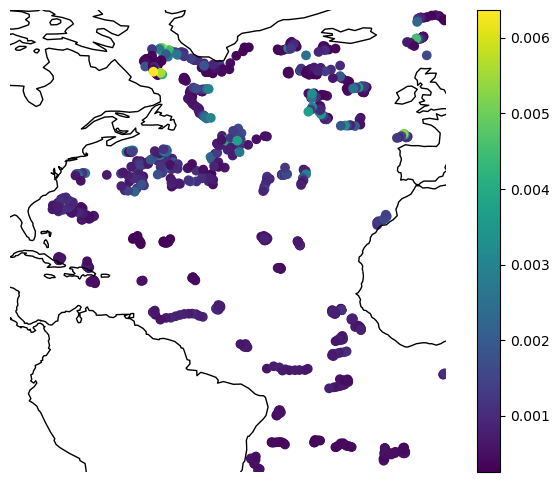

In [37]:
proj = cartopy.crs.PlateCarree()
fig = plt.figure(figsize=(8, 6), )
ax = fig.add_subplot(projection=proj, frameon=False)

# cc = ax.scatter(df.loc[:,'LONGITUDE'], df.loc[:,'LATITUDE'],
#            c =  df.loc[:,'DOXY'],
#            transform=cartopy.crs.PlateCarree())
pcm = ax.scatter(float_bbp.loc[:,'LONGITUDE'], float_bbp.loc[:,'LATITUDE'], 
            c = float_bbp.loc[:,'BBP700'])
cbar = fig.colorbar(pcm, ax=ax)
ax.add_feature(cartopy.feature.COASTLINE)
ax.set_xlim(lon0,lon1)
ax.set_ylim(lat0,lat1)

In [21]:
# Satellite Matchup Constants
# Short names for earthaccess lookup
SAT_LOOKUP = {
    "PACE_AOP": "PACE_OCI_L2_AOP",
    "PACE_IOP": "PACE_OCI_L2_IOP",
    "PACE_BGC": "PACE_OCI_L2_BGC",
    "AQUA": "MODISA_L2_OC",
    "TERRA": "MODIST_L2_OC",
    "NOAA-20": "VIIRSJ1_L2_OC",
    "NOAA-21": "VIIRSJ2_L2_OC",
    "SUOMI-NPP": "VIIRSN_L2_OC",
}

# List l2 flags, then build them into a dict
l2_flags_list = [
    "ATMFAIL",
    "LAND",
    "PRODWARN",
    "HIGLINT",
    "HILT",
    "HISATZEN",
    "COASTZ",
    "SPARE",
    "STRAYLIGHT",
    "CLDICE",
    "COCCOLITH",
    "TURBIDW",
    "HISOLZEN",
    "SPARE",
    "LOWLW",
    "CHLFAIL",
    "NAVWARN",
    "ABSAER",
    "SPARE",
    "MAXAERITER",
    "MODGLINT",
    "CHLWARN",
    "ATMWARN",
    "SPARE",
    "SEAICE",
    "NAVFAIL",
    "FILTER",
    "SPARE",
    "BOWTIEDEL",
    "HIPOL",
    "PRODFAIL",
    "SPARE",
]
L2_FLAGS = {flag: 1 << idx for idx, flag in enumerate(l2_flags_list)}

# Bailey and Werdell 2006 exclusion criteria
EXCLUSION_FLAGS = [
    "LAND",
    "HIGLINT",
    "HILT",
    "STRAYLIGHT",
    "CLDICE",
    "ATMFAIL",
    "LOWLW",
    "FILTER",
    "NAVFAIL",
    "NAVWARN",
]



##---------------------------------------------------------------------------##
#                             Satellite Utilities                             #
##---------------------------------------------------------------------------##


def parse_quality_flags(flag_value):
    """Parse bitwise flag into a list of flag names.

    Parameters
    ----------
    flag_value : int
        The integer representing the combined bitwise quality flags.

    Returns
    -------
    list of str
        List of flag names that are set in the flag_value.

    """
    return [
        flag_name for flag_name, value in L2_FLAGS.items()
        if (flag_value & value) != 0
    ]


def get_fivebyfive(file, latitude, longitude, rrs_wavelengths):
    """Get stats on 5x5 box around station coordinates of a satellite granule.

    This checks l2flags and runs statistics on valid pixels and returns their
    valid count, the coefficient of variance (cv), and the Rrs values.

    Parameters
    ----------
    file : earthaccess granule object
        Satellite granule from earthaccess.
    latitude : float
        In decimal degrees for Aeronet-OC site for matchups
    longitude : float
        In decimal degrees (negative West) for Aeronet-OC site for matchups
    rrs_wavelengths ; numpy array
        Rrs wavelengths (from wavelength_3d for OCI)

    Returns
    -------
    dict
        A dictionary of the processed 5x5 box with:
            - "sat_datetime": pd.datetime
                Datetime of the overall granule start time
            - "sat_cv": float
                Median coefficient of variation of Rrs(405nm - 570nm)
            - "sat_latitude": float
                Latitude of center pixel
            - "sat_longitude": float
                Longitude of center pixel
            - "sat_pixel_valid": float
                Number of valid pixels in 5x5 box based on l2 flags

    Notes
    -----
    This is set to use just Rrs data for the demo. As an exercise, make this
    function more generalized by adding an input for the desired product and
    removing the wavelength dependency (if not needed) as well as the cv
    calculation. This will also require refactoring the `match_data` function.
    """
    with xr.open_dataset(file, group="navigation_data") as ds_nav:
        sat_lat = ds_nav["latitude"].values
        sat_lon = ds_nav["longitude"].values

    # Calculate the Euclidean distance for 2D lat/lon arrays
    distances = np.sqrt((sat_lat - latitude) ** 2 + (sat_lon - longitude) ** 2)

    # Find the index of the minimum distance
    # Dimensions are (lines, pixels)
    min_dist_idx = np.unravel_index(np.argmin(distances), distances.shape)
    center_line, center_pixel = min_dist_idx

    # Get indices for a 5x5 box around the center pixel
    line_start = max(center_line - 2, 0)
    line_end = min(center_line + 2 + 1, sat_lat.shape[0])
    pixel_start = max(center_pixel - 2, 0)
    pixel_end = min(center_pixel + 2 + 1, sat_lat.shape[1])

    # Extract the data
    # NOTE: This is hard-coded to Rrs from an L2 AOP file.
    with xr.open_dataset(file, group="geophysical_data") as ds_data:
        rrs_data = (
            ds_data["Rrs"].isel(
                number_of_lines=slice(line_start, line_end),
                pixels_per_line=slice(pixel_start, pixel_end),
            ).values
        )
        flags_data = (
            ds_data["l2_flags"].isel(
                number_of_lines=slice(line_start, line_end),
                pixels_per_line=slice(pixel_start, pixel_end),
            ).values
        )

    # Calculate the bitwise OR of all flags in EXCLUSION_FLAGS to get a mask
    exclude_mask = sum(L2_FLAGS[flag] for flag in EXCLUSION_FLAGS)

    # Create a boolean mask
    # True means the flag value does not contain any of the EXCLUSION_FLAGS
    valid_mask = np.bitwise_and(flags_data, exclude_mask) == 0

    # Get stats and averages
    if valid_mask.any():
        rrs_valid = rrs_data[valid_mask]
        rrs_std_initial = np.std(rrs_valid, axis=0)
        rrs_mean_initial = np.mean(rrs_valid, axis=0)

        # Exclude spectra > 1.5 stdevs away
        std_mask = np.all(
            np.abs(rrs_valid - rrs_mean_initial) <= 1.5 * rrs_std_initial,
            axis=1
        )
        rrs_std = np.std(rrs_valid[std_mask], axis=0)
        rrs_mean = np.mean(rrs_valid[std_mask], axis=0).flatten()

        # Matchup criteria uses cv as median of 405-570nm
        rrs_cv = rrs_std / rrs_mean
        rrs_cv_median = np.median(
            rrs_cv[(rrs_wavelengths >= 405) & (rrs_wavelengths <= 570)]
        )
    else:
        rrs_cv_median = np.nan
        rrs_mean = np.nan * np.empty_like(rrs_wavelengths)

    # Put in dictionary of the row
    row = {
        "sat_datetime": pd.to_datetime(
            file.granule["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"],
            utc=0
        ),
        "sat_cv": rrs_cv_median,
        "sat_latitude": sat_lat[center_line, center_pixel],
        "sat_longitude": sat_lon[center_line, center_pixel],
        "sat_pixel_valid": np.sum(valid_mask),
    }

    # Add mean spectra to the row dictionary
    for wavelength, mean_value in zip(rrs_wavelengths, rrs_mean):
        key = f"sat_rrs{int(wavelength)}"
        row[key] = mean_value

    return row

In [22]:
def get_sat_ts_matchups(
    start_date,
    end_date,
    latitude,
    longitude,
    sat="PACE_AOP",
    selected_dates=None
):
    """Make satellite timeseries of matchups from single station.

    Caution: If the date or coordinates aren't formatted correctly, it might
    pull a huge granule list and take forever to run. If it takes more than 45
    seconds to print the number of granules, just kill the process.

    Uses the earthaccess package. Defaults to the PACE OCI L2 IOP datasets,
    but other satellites can be used if they have a corresponding short_name
    in the SAT_LOOKUP dictionary.

    Workflow:
        1. Get list of matchup granules
        2. Loop through each file and:
            2a. Find closest pixel to station, extract 5x5 pixel box
            2b. Exclude pixels based on l2_flags
            2c. Filtered mean to get single spectra
            2d. Compute statistics and save data row
        3. Organize output pandas dataframe

    Parameters
    ----------
    start_date : datetime or str
        Beginning of Aeronet data to run.
    end_date : datetime or str, optional
        End of Aeronet data to run.
    latitude : float
        In decimal degrees for Aeronet-OC site for matchups
    longitude : float
        In decimal degrees (negative West) for Aeronet-OC site for matchups
    sat : str
        Name of satellite to search. Must be in SAT_LOOKUP dict constant.
    selected_dates : list of str, optional
        If given, only pull granules if the dates are in this list

    Returns
    -------
    pandas DataFrame object
        Flattened table of all satellite granule matchups.

    """
    # Look up short name from constants
    if sat not in SAT_LOOKUP.keys():
        raise ValueError(
            f"{sat} is not in the lookup dictionary. Available "
            f"sats are: {', '.join(SAT_LOOKUP)}"
        )
    short_name = SAT_LOOKUP[sat]

    # Format search parameters
    # time_bounds = (f"{start_date}T00:00:00", f"{end_date}T23:59:59")
    time_bounds = (start_date, end_date)
    
    # Run Earthaccess data search
    results = earthaccess.search_data(
        point=(longitude, latitude),
        temporal=time_bounds,
        short_name=short_name
    )
    if selected_dates is not None:
        filtered_results = [
            result
            for result in results
            if result["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"][:10]
            in selected_dates
        ]
        print(f"Filtered to {len(filtered_results)} Granules.")
        files = earthaccess.open(filtered_results)
    else:
        files = earthaccess.open(results)

    # Pull out Rrs wavelengths for easier processing
    with xr.open_dataset(files[0], group="sensor_band_parameters") as ds_bands:
        rrs_wavelengths = ds_bands["wavelength_3d"].values

    # Loop through files and process
    sat_rows = []
    for idx, file in enumerate(files):
        granule_date = pd.to_datetime(
            file.granule["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"]
        )
        print(f"Running Granule: {granule_date}")
        row = get_fivebyfive(file, latitude, longitude, rrs_wavelengths)
        sat_rows.append(row)

    return pd.DataFrame(sat_rows)